# **A study of the correlation of religion with social and economic factors**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import plotly.express as px
import json

# Install geopandas and its dependencies for handling GeoJSON files.
import sys
!{sys.executable} -m pip install geopandas fiona


 First, we load the data that was provided to us for the project and look at the first 5 elements from each table to make sure everything is in order.

First table:

In [ ]:
# Желательно тут использовать данные, которые обработал Паша (Если Паша читает, то склеивать надо тут)
link_for_importance = "https://ourworldindata.org/grapher/how-important-religion-is-in-your-life.csv?v=1&csvType=full&useColumnShortNames=true"
importance = pd.read_csv(link_for_importance, storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
display(importance.head())

,entity,code,year,very_important_in_life_religion,rather_important_in_life_religion,not_very_important_in_life_religion,notatall_important_in_life_religion,dont_know_important_in_life_religion,no_answer_important_in_life_religion,very_important_in_life_religion__annotations,rather_important_in_life_religion__annotations,not_very_important_in_life_religion__annotations,notatall_important_in_life_religion__annotations,dont_know_important_in_life_religion__annotations,no_answer_important_in_life_religion__annotations
0,Albania,ALB,1998,24.22422,34.534530,28.228230,10.71071,2.302302,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,Albania,ALB,2004,27.50000,31.200000,25.200000,14.20000,1.900000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2,Albania,ALB,2010,15.71519,35.645400,27.452140,18.17237,1.967477,1.047418,NaN,NaN,NaN,NaN,NaN,NaN
3,Albania,ALB,2022,24.36961,48.684380,15.685870,10.84857,0.061695,0.349869,NaN,NaN,NaN,NaN,NaN,NaN
4,Algeria,DZA,2004,90.63963,7.488299,0.936037,NaN,0.936037,0.000000,NaN,NaN,NaN,NaN,NaN,NaN


Second table:

In [ ]:
# Желательно тут использовать данные, которые обработал Паша (Если Паша читает, то склеивать надо тут)
link_for_number = "https://ourworldindata.org/grapher/number-of-people-by-religion.csv?v=1&csvType=full&useColumnShortNames=true"
number = pd.read_csv(link_for_number, storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
display(number.head())

,entity,code,year,count__religion_buddhists,count__religion_hindus,count__religion_muslims,count__religion_jews,count__religion_christians,count__religion_religiously_unaffiliated,count__religion_other_religions
0,Afghanistan,AFG,2010,< 10000,< 10000,28210000,< 10000,30000,< 10000,30000
1,Afghanistan,AFG,2020,< 10000,< 10000,39020000,< 10000,< 10000,< 10000,40000
2,Africa,OWID_AFR,2010,8,134,48085,9,53658,2712,2615
3,Africa,OWID_AFR,2020,10,147,61814,6,70314,3007,2784
4,Albania,ALB,2010,< 10000,< 10000,2050000,< 10000,590000,280000,< 10000


Looking at the data in the “importance” table (the first table), we realized that it’s a bit difficult to judge the level of religiosity in this country. We have many metrics that, to varying degrees, reflect the level of religiosity in this country.

Let me give an example: let’s look at the figures for Albania in 1998 and 2004. At first glance, it seems that people were more religious in 2004, since the percentage in the “very_important_in_life_religion” column is higher (24% and 27%), but in 2004 there is also a higher percentage of “not_at_all_important_in_life_religion” (10% and 15%), and in 2004 there is a lower percentage of “rather_important_in_life_religion” (34% and 31%) and “not_very_important_in_life_religion” (28% and 25%).
Due to the factors listed above, it becomes difficult to determine in which year people were more religious

And, for the sake of generalization and visual-logical simplification, we decided to combine the columns listed above into a single value

We examined two formulas for calculating this coefficient.

(Тут Вання предлагал по красивому переделать, я ХЗ как)




---

WRL = ( V * 1 + R * 0.66+ NV * 0.33 + N * 0) / SUM

WRL - Weighted Religiousness Linear

V - very_important_in_life_religion

R - rather_important_in_life_religion

NV - not_very_important_in_life_religion

N - notatall_important_in_life_religion

SUM - sum equal (V + R + NV + N)

---



---


WRE = ( V * 1 + R * 0.5 + NV * 0.1 + N * 0) / SUM

WRE - Weighted Religiousness Expanantial

V - very_important_in_life_religion

R - rather_important_in_life_religion

NV - not_very_important_in_life_religion

N - notatall_important_in_life_religion

SUM - sum equal (V + R + NV + N)



---





We use different formulas because, although at first glance it seems that the coefficients can be distributed evenly (as is done in the linear formula), in practice the difference between the beliefs of a strong believer and a lesser believer is colossal (which is taken into account in the exponential formula).


In [ ]:
# We create a list of columns for convenience
cols = [
    'very_important_in_life_religion',
    'rather_important_in_life_religion',
    'not_very_important_in_life_religion',
    'notatall_important_in_life_religion'
]

# We calculate the sum
# We use fillna(0) so that NaN doesn't mess up the sum
# But it is important to check if all values ​​in the string are NaN

temp_df = importance[cols].fillna(0)

# Calculate Weighted Religiousness Linear
importance['weighted_religiousness_linear'] = (
    temp_df['very_important_in_life_religion'] * 1 +
    temp_df['rather_important_in_life_religion'] * 0.66 +
    temp_df['not_very_important_in_life_religion'] * 0.33 +
    temp_df['notatall_important_in_life_religion'] * 0
) / temp_df.sum(axis=1)

# Calculate Weighted Religiousness Expanantials
importance['weighted_religiousness_exp'] = (
    temp_df['very_important_in_life_religion'] * 1 +
    temp_df['rather_important_in_life_religion'] * 0.5 +
    temp_df['not_very_important_in_life_religion'] * 0.1 +
    temp_df['notatall_important_in_life_religion'] * 0
) / temp_df.sum(axis=1)


# Optional: if row_sum was 0, replace inf with NaN
importance['weighted_religiousness_linear'] = importance['weighted_religiousness_linear'].replace([np.inf, -np.inf], np.nan)
importance['weighted_religiousness_exp'] = importance['weighted_religiousness_exp'].replace([np.inf, -np.inf], np.nan)

Now let's see how the changed importance_table looks like.

In [ ]:
display(importance.head())

,entity,code,year,very_important_in_life_religion,rather_important_in_life_religion,not_very_important_in_life_religion,notatall_important_in_life_religion,dont_know_important_in_life_religion,no_answer_important_in_life_religion,very_important_in_life_religion__annotations,rather_important_in_life_religion__annotations,not_very_important_in_life_religion__annotations,notatall_important_in_life_religion__annotations,dont_know_important_in_life_religion__annotations,no_answer_important_in_life_religion__annotations,weighted_religiousness_linear,weighted_religiousness_exp
0,Albania,ALB,1998,24.22422,34.534530,28.228230,10.71071,2.302302,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.576598,0.453586
1,Albania,ALB,2004,27.50000,31.200000,25.200000,14.20000,1.900000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.575005,0.465036
2,Albania,ALB,2010,15.71519,35.645400,27.452140,18.17237,1.967477,1.047418,NaN,NaN,NaN,NaN,NaN,NaN,0.498018,0.374110
3,Albania,ALB,2022,24.36961,48.684380,15.685870,10.84857,0.061695,0.349869,NaN,NaN,NaN,NaN,NaN,NaN,0.619325,0.504882
4,Algeria,DZA,2004,90.63963,7.488299,0.936037,NaN,0.936037,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.967969,0.953701


Now let's create a copy of this table, dropping the values ​​we don't need.

In [ ]:
weighted_religiousness_table = importance[['entity','code', 'year', 'weighted_religiousness_linear', 'weighted_religiousness_exp']]
display(weighted_religiousness_table.head(10))

,entity,code,year,weighted_religiousness_linear,weighted_religiousness_exp
0,Albania,ALB,1998,0.576598,0.453586
1,Albania,ALB,2004,0.575005,0.465036
2,Albania,ALB,2010,0.498018,0.374110
3,Albania,ALB,2022,0.619325,0.504882
4,Algeria,DZA,2004,0.967969,0.953701
5,Algeria,DZA,2014,0.960117,0.946689
6,Andorra,AND,2010,0.323090,0.217153
7,Andorra,AND,2022,0.342475,0.233633
8,Argentina,ARG,1993,0.632189,0.542369
9,Argentina,ARG,1998,0.630249,0.530607


I'd like to point out the significance of the previously mentioned examples (Albania in 1998 and 2004).

According to the linear formula, people were more religious in 1998, while if we rely on the exponential formula, they were more religious in 2004.

# Я НЕ ЗНАЮ ЧТО ДЕЛАТЬ С ЭТОЙ ЧАСТЬЮ


ОТ СЮДА

### Average Religiousness Over Years with Trend Lines

This plot visualizes the trend of average religiousness (both linear and exponential calculations) across different years, including statistical trend lines to highlight any overall direction in the data.

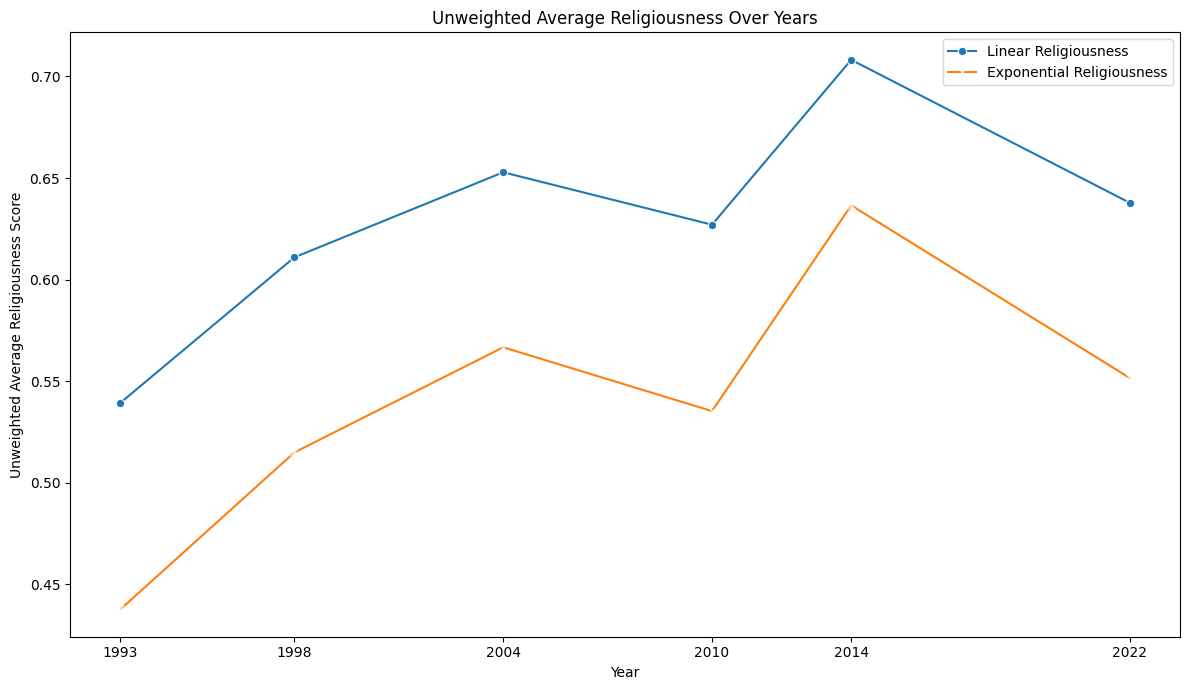

In [ ]:
# Filter for years where religiousness data is available
# The 'importance' DataFrame already has weighted_religiousness_linear and _exp calculated.

# The 'total_respondents' column will be removed, as the user requested an unweighted average.
# Filter out rows with NaN religiousness scores before calculating the unweighted average
filtered_importance = importance.dropna(subset=['weighted_religiousness_linear', 'weighted_religiousness_exp']).copy()

# Function to calculate unweighted mean
def unweighted_mean(df, value_col):
    # Calculate the simple mean of the value_col
    return df[value_col].mean()

# Group by year and apply the unweighted mean calculation
annual_religiousness = filtered_importance.groupby('year').apply(
    lambda x: pd.Series({
        'weighted_religiousness_linear': unweighted_mean(x, 'weighted_religiousness_linear'),
        'weighted_religiousness_exp': unweighted_mean(x, 'weighted_religiousness_exp')
    }), include_groups=False
).reset_index()

# Plotting the trends
plt.figure(figsize=(12, 7))

# Plotting the data points and connecting lines
sns.lineplot(x='year', y='weighted_religiousness_linear', data=annual_religiousness, marker='o', label='Linear Religiousness')
sns.lineplot(x='year', y='weighted_religiousness_exp', data=annual_religiousness, marker='x', label='Exponential Religiousness')

plt.title('Unweighted Average Religiousness Over Years')
plt.xlabel('Year')
plt.ylabel('Unweighted Average Religiousness Score')
# plt.grid(True, linestyle='--', alpha=0.7) # Removed grid lines as per user request
plt.xticks(annual_religiousness['year'].unique()) # Ensure all years with data are shown as ticks
plt.legend()
plt.tight_layout()
plt.show()

ДО СЮДА

Часть ниже - фикс карты с Крымом

(Если Паша , снова таки, это читает - то склеивать эту часть надо с Фединым кодом. Только дай бог тебе силы воли, т.к. я на 90 % уверен что Ваня и Федя использовали немного разные методы загрузки файла и есть немалая вероятность того что если просто тупо склеить, то что то наебнеться) (Коментарии на эту часть кода оставляю Феди, т.к. он этим занимался и лучше чем он не объяснит)

In [ ]:
GEOJSON_PATH = "/content/countries_ukraine_crimea.geojson"

ukraine_crimea_geojson = None
try:
    # Attempt to read as a file path first, then as a URL
    if GEOJSON_PATH.startswith('http'):
        ukraine_crimea_geojson = gpd.read_file(GEOJSON_PATH)
    else:
        ukraine_crimea_geojson = gpd.read_file(GEOJSON_PATH)
    print(f"Successfully loaded GeoJSON from {GEOJSON_PATH}")
except Exception as e:
    print(f"Error loading GeoJSON from {GEOJSON_PATH}: {e}")
    print("Please ensure the path or URL is correct and the file is accessible.")
    print("The map will use default boundaries if the custom GeoJSON cannot be loaded.")

Error loading GeoJSON from /content/countries_ukraine_crimea.geojson: /content/countries_ukraine_crimea.geojson: No such file or directory
Please ensure the path or URL is correct and the file is accessible.
The map will use default boundaries if the custom GeoJSON cannot be loaded.


Next, we will display a map of countries, with a color scheme tied to the weighted "_religiousness_linear" , but, in addition to this, we will display values ​​from the table 'numbers' in percentage form when hovering over a particular country.

In [ ]:
# Припустимо, що ukraine_crimea_geojson завантажено з попередньої клітинки.
# Якщо ні, то змінна буде None, і буде використано стандартні межі карти.

# Припустимо, що 'number' DataFrame вже містить колонки з кількістю релігійних груп.
# Також розрахуємо загальну кількість людей для подальшого обчислення відсотків.

# Визначаємо список колонок, що містять дані про кількість представників різних релігій
religion_cols = ['count__religion_buddhists', 'count__religion_hindus', 'count__religion_muslims', 'count__religion_jews', 'count__religion_christians', 'count__religion_religiously_unaffiliated', 'count__religion_other_religions']

# Перетворюємо колонки з кількістю релігій на числовий тип.
# Усі помилки при перетворенні (наприклад, нечислові значення) будуть перетворені на NaN,
# а потім NaN будуть замінені на 0, щоб уникнути проблем при розрахунках.
for col in religion_cols:
    number[col] = pd.to_numeric(number[col], errors='coerce').fillna(0)

# 1. Рахуємо сумарне населення (всі релігії) для кожного рядка, щоб отримати відсотки.
# Сумуємо значення по всіх колонках релігій для кожного рядка.
number['total_population'] = number[religion_cols].sum(axis=1)

# Злиття 'number' DataFrame з 'importance' DataFrame.
# Мета — додати колонку 'weighted_religiousness_linear' до 'number' DataFrame,
# використовуючи спільні колонки 'entity', 'code' та 'year'.
# 'how='left'' означає, що всі записи з 'number' будуть збережені.
merged_df = pd.merge(number, importance[['entity', 'code', 'year', 'weighted_religiousness_linear']],
                     on=['entity', 'code', 'year'], how='left')

# Визначаємо словник для перетворення технічних назв релігійних колонок на більш зрозумілі українські назви.
religion_name_map = {
    'count__religion_buddhists': 'Buddhists',
    'count__religion_hindus': 'Hindus',
    'count__religion_muslims': 'Muslims',
    'count__religion_jews': 'Jews',
    'count__religion_christians': 'Christians',
    'count__religion_religiously_unaffiliated': 'Religiously Unaffiliated',
    'count__religion_other_religions': 'Other Religions'
}

# Створюємо нову колонку 'custom_hover_info' для зберігання відформатованого тексту,
# який буде відображатися у спливаючій підказці (hover tooltip).
merged_df['custom_hover_info'] = ''

# Проходимося по кожному рядку 'merged_df' для формування детальної інформації про релігійний склад.
for index, row in merged_df.iterrows():
    religion_percentages_list = []
    for rel_base_col in religion_cols:
        # Отримуємо загальну кількість населення та кількість представників поточної релігії для поточного рядка.
        total_pop = row['total_population']
        rel_count = row[rel_base_col]

        # Обчислюємо відсоток, якщо загальне населення не є NaN і не дорівнює 0.
        if pd.isna(total_pop) or total_pop == 0:
            percent_value = np.nan
        else:
            percent_value = (rel_count / total_pop) * 100

        # Отримуємо зрозумілу назву релігії та додаємо її до списку разом з відсотком.
        human_name = religion_name_map.get(rel_base_col, rel_base_col)
        religion_percentages_list.append({'name': human_name, 'value': percent_value})

    # Фільтруємо список: видаляємо NaN відсотки та сортуємо за значенням (від більшого до меншого).
    # Також включаємо лише відсотки > 0.
    sorted_percentages = sorted(
        [item for item in religion_percentages_list if not pd.isna(item['value']) and item['value'] > 0],
        key=lambda x: x['value'],
        reverse=True
    )

    # Форматуємо відсортовані відсотки у рядок для відображення у спливаючій підказці.
    if sorted_percentages:
        # Додаємо заголовок для ясності, потім список релігій з відсотками.
        hover_lines = ['<b>Religious composition:</b>'] + [f"{item['name']}: {item['value']:.1f}%" for item in sorted_percentages]
        merged_df.loc[index, 'custom_hover_info'] = '<br>'.join(hover_lines)
    else:
        # Якщо даних немає, вказуємо відповідне повідомлення.
        merged_df.loc[index, 'custom_hover_info'] = 'Religious composition data not available.'


# 3. Будуємо карту
# Перевіряємо, чи був успішно завантажений кастомний GeoJSON (ukraine_crimea_geojson) у попередній клітинці.
if 'ukraine_crimea_geojson' in locals() and ukraine_crimea_geojson is not None:
    print("Using custom GeoJSON for map boundaries.") # Виводимо повідомлення, що використовується кастомний GeoJSON.
    world_gdf = ukraine_crimea_geojson.copy() # Створюємо копію GeoDataFrame.

    # Перейменовуємо колонки в world_gdf, щоб вони відповідали тим, що використовуються для злиття/зіставлення.
    # 'name' перейменовуємо в 'entity_name_map' (може бути використано для hover_name).
    # 'ISO3166-1-Alpha-3' перейменовуємо в 'iso_a3_map' (це ключ для зіставлення).
    world_gdf = world_gdf.rename(columns={
        "name": "entity_name_map",
        "ISO3166-1-Alpha-3": "iso_a3_map"
    })
    # Вибираємо лише необхідні колонки для GeoJSON даних, включаючи геометрію.
    world_gdf = world_gdf[["iso_a3_map", "geometry", "entity_name_map"]].copy()

    # Діагностичний вивід для перевірки ключів зіставлення.
    print("Sample of 'code' from merged_df:", merged_df['code'].dropna().unique()[:5])
    print("Sample of 'iso_a3_map' from world_gdf:", world_gdf['iso_a3_map'].dropna().unique()[:5])

    # Перетворюємо GeoDataFrame на словник GeoJSON для надійності.
    # Це гарантує, що Plotly використовуватиме наданий GeoJSON безпосередньо,
    # а не буде потенційно повертатися до стандартних меж.
    geojson_dict = json.loads(world_gdf.to_json())

    # Створюємо хорізматичну карту за допомогою Plotly Express.
    fig = px.choropleth(
        merged_df, # Використовуємо DataFrame зі статистичними даними.
        geojson=geojson_dict, # Передаємо словник GeoJSON.
        locations="code", # Колонка в merged_df, яка відповідає за ідентифікатори регіонів.
        featureidkey="properties.iso_a3_map", # Шлях до ідентифікатора регіону всередині властивостей GeoJSON.
        color="weighted_religiousness_linear",  # Колонка, за якою буде відбуватися розфарбовування карти (твоя нова фіча).
        # hover_name="entity", # Закоментовано, щоб уникнути конфлікту з custom hovertemplate, оскільки назва вже в customdata.
        # Додаємо дані для відображення у спливаючій підказці.
        hover_data={
            "entity": True, # Явно додаємо 'entity' до hover_data.
            "code": True, # Додаємо 'code' країни.
            "weighted_religiousness_linear": ":.2f" # Додаємо 'weighted_religiousness_linear', форматовану до 2 знаків після коми.
        },
        title="World Religiousness Index by Country (2010) with custom GeoJSON", # Заголовок карти.
        color_continuous_scale="Viridis", # Використовуємо шкалу кольорів 'Viridis' для кращої візуалізації градієнта 0...1.
        range_color=[0, 1], # Встановлюємо діапазон кольорів від 0 до 1.
        labels={'weighted_religiousness_linear': 'Overall Religiousness'} # Перейменовуємо мітку для колірної панелі.
    )
else:
    # Якщо кастомний GeoJSON не завантажено, виводимо попередження та використовуємо стандартні межі карти.
    print("Warning: Custom GeoJSON for Crimea not loaded. Falling back to default map boundaries.")
    fig = px.choropleth(
        merged_df, # Використовуємо об'єднаний DataFrame.
        locations="code", # Колонка з кодами країн для зіставлення зі стандартними межами Plotly.
        color="weighted_religiousness_linear",  # Колонка для розфарбовування.
        # hover_name="entity", # Закоментовано, оскільки назва вже в customdata.
        hover_data={
            "entity": True, # Явно додаємо 'entity' до hover_data.
            "code": True, # Додаємо 'code' країни.
            "weighted_religiousness_linear": ":.2f" # Додаємо 'weighted_religiousness_linear', форматовану до 2 знаків після коми.
        },
        title="World Religiousness Index by Country (2010)", # Заголовок карти для випадку без кастомного GeoJSON.
        color_continuous_scale="Viridis", # Шкала кольорів.
        range_color=[0, 1],
        labels={'weighted_religiousness_linear': 'Religiousness'} # Мітка для колірної панелі.
    )

# Оновлюємо сліди (traces) карти для налаштування спливаючої підказки (hover template).
# Передаємо 'entity' та 'custom_hover_info' як customdata, щоб їх можна було використовувати в hovertemplate.
# 'customdata[0]' буде відповідати 'entity', а 'customdata[1]' — 'custom_hover_info'.
fig.update_traces(customdata=merged_df[['entity', 'custom_hover_info']],
                  hovertemplate='<b>%{customdata[0]}</b><br>Code: %{location}<br>Overall Religiousness: %{z:.2f}<br>%{customdata[1]}')

# Трохи підправимо вигляд, щоб карта була на весь екран.
fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0}) # Встановлюємо відступи для компонування.
fig.show() # Відображаємо карту.

To conduct further research, we will use a table provided to us in one of the lectures.

In [ ]:
url = 'https://fmfi-compbio.github.io/viz/data/World_bank.csv'
countries = pd.read_csv(url).set_index('Country')
display(countries.head(5))

,ISO3,Region,Income Group,Population2000,Population2010,Population2020,Area,GDP2000,GDP2010,GDP2020,Expectancy2000,Expectancy2010,Expectancy2020,Fertility2000,Fertility2010,Fertility2020
Country,,,,,,,,,,,,,,,,
Afghanistan,AFG,South Asia,Low income,19542983.0,28189672.0,38972231.0,652860.0,NaN,562.499219,512.055098,55.298,60.851,62.575,7.534,6.099,4.750
Albania,ALB,Europe & Central Asia,Upper middle income,3089026.0,2913021.0,2837849.0,28750.0,1126.683340,4094.349686,5343.037704,75.404,77.936,76.989,2.231,1.656,1.400
Algeria,DZA,Middle East & North Africa,Lower middle income,30774621.0,35856344.0,43451666.0,2381741.0,1780.376063,4495.921476,3354.153164,70.478,73.808,74.453,2.566,2.843,2.942
American Samoa,ASM,East Asia & Pacific,High income,58229.0,54849.0,46189.0,200.0,NaN,10446.863206,15609.777220,NaN,NaN,NaN,NaN,NaN,NaN
Andorra,AND,Europe & Central Asia,High income,66097.0,71519.0,77699.0,470.0,21620.465102,48237.890541,37207.238871,NaN,NaN,NaN,NaN,1.270,NaN


Next, we'll compare the data from this table for 2010 and 2020 with our religiosity values. But then we need to check whether we have the values ​​for our coefficients for those years.

In [ ]:
# Filter the dataframe by the desired years
years_to_check = [2008, 2009, 2010, 2011, 2012 , 2018, 2019, 2020, 2021, 2022]
filtered_df = importance[importance['year'].isin(years_to_check)]

# Let's see how many unique countries there are for each year
print("\nUnique countries per year in years_to_check:")
print(filtered_df.groupby('year')['entity'].nunique())

# We get unique countries for which there is data in 2020
countries_2020 = importance[importance['year'] == 2020]['entity'].unique()
print("Countries with data in 2020:")
for country in countries_2020:
    print(f"- {country}")



Unique countries per year in years_to_check:
year
2010    81
2022    92
Name: entity, dtype: int64
Countries with data in 2020:


As we see, a small problem arises: we do not have data specifically for 2020, but we do have data for 2022. Therefore, it was decided to ignore the small difference in years, since the results for two years cannot be significant in any way.

Based on these tables, we want to present a visualization of the importance of religion within each Income group.

In [ ]:
countries_prep = countries.reset_index().rename(columns={'Country': 'entity', 'ISO3': 'code'})



In [ ]:

# 1. Отримуємо найактуальніші дані для importance та number DataFrame
#    Ці функції коректно отримують дані за найактуальніший рік для кожної сутності у відповідних датафреймах.
latest_importance = get_most_recent_year_data(importance, 2022, 2020)
latest_number = get_most_recent_year_data(number, 2022, 2020)

# 2. Зливаємо importance та number для отримання total_population разом з відсотками важливості релігії.
#    Змінено: тепер об'єднання відбувається лише за 'entity' та 'code'.
#    Це дозволяє об'єднувати дані, навіть якщо найактуальніші роки для показників важливості
#    та населення відрізняються для однієї і тієї ж країни. Рік зберігається як year_importance та year_number.
df_merged_religion_pop = pd.merge(latest_importance, latest_number[['entity', 'code', 'year', 'total_population']],
                                 on=['entity', 'code'],
                                 how='inner',
                                 suffixes=('_importance', '_number'))

# 3. Зливаємо з countries_prep для додавання колонки 'Income Group'
final_df_for_pie = pd.merge(df_merged_religion_pop, countries_prep, on='code', how='inner')

# 4. Визначаємо колонки, що містять відсотки відповідей щодо важливості релігії
importance_percentage_cols = [
    'very_important_in_life_religion',
    'rather_important_in_life_religion',
    'not_very_important_in_life_religion',
    'notatall_important_in_life_religion'
]

# Заповнюємо NaN у відсоткових колонках нулями, перш ніж їх використовувати для розрахунків.
# Це важливо, оскільки відсутність даних може означати 0% для цієї категорії.
for col in importance_percentage_cols:
    final_df_for_pie[col] = final_df_for_pie[col].fillna(0)

# 5. Розраховуємо абсолютну кількість людей для кожної категорії важливості релігії
# 'total_population' з df_merged_religion_pop (який тепер є частиною final_df_for_pie)
# відображає суму всіх релігійних груп для найактуальнішого року.
# Ми припускаємо, що відсотки в importance_percentage_cols застосовуються до цього 'total_population'.
for col in importance_percentage_cols:
    # Нова колонка буде мати префікс 'abs_' та назву оригінальної колонки
    # Важливо: ділимо на 100, оскільки 'importance_percentage_cols' містять відсотки (наприклад, 24.36 замість 0.2436)
    final_df_for_pie['abs_' + col] = (final_df_for_pie[col] / 100) * final_df_for_pie['total_population']

# Створюємо список нових колонок з абсолютними числами
abs_importance_cols = ['abs_' + col for col in importance_percentage_cols]

# 6. Групуємо дані за 'Income Group' та підсумовуємо абсолютні кількості
aggregated_abs_counts = final_df_for_pie.groupby('Income Group')[abs_importance_cols].sum().reset_index()

# 7. Перетворюємо агреговані дані з широкого формату на довгий (melt) для побудови кругових діаграм
melted_abs_data = aggregated_abs_counts.melt(id_vars='Income Group', var_name='Religious Importance', value_name='Absolute Number of People')

# 8. Змінюємо технічні назви колонок на більш зрозумілі для відображення на графіку
response_map_abs = {
    'abs_very_important_in_life_religion': 'Very Important',
    'abs_rather_important_in_life_religion': 'Rather Important',
    'abs_not_very_important_in_life_religion': 'Not Very Important',
    'abs_notatall_important_in_life_religion': 'Not at all Important'
}
melted_abs_data['Religious Importance'] = melted_abs_data['Religious Importance'].map(response_map_abs)

# Фільтруємо рядки, де 'Absolute Number of People' є NaN або 0, щоб уникнути їх відображення на діаграмі.
melted_abs_data = melted_abs_data[melted_abs_data['Absolute Number of People'].notna() & (melted_abs_data['Absolute Number of People'] > 0)]

# 9. Створюємо кругові діаграми за допомогою Plotly Express
# Використовуємо facet_col для створення окремих діаграм для кожної 'Income Group'
fig = px.pie(melted_abs_data,
             values='Absolute Number of People',
             names='Religious Importance',
             facet_col='Income Group',
             facet_col_wrap=2, # Обгортаємо фасети після 2 стовпців
             title='<b>Distribution of Religious Importance by Income Group (Absolute Numbers)</b>', # Зроблено жирним
             hole=0.3, # Створюємо "бублик" для кращої читабельності
             color_discrete_sequence=px.colors.sequential.Viridis, # Використовуємо послідовну колірну схему
             labels={'Absolute Number of People': 'Number of People'},
             # Встановлюємо бажаний порядок для груп доходів безпосередньо в px.pie
             category_orders={'Income Group': ['High income','Low income', 'Upper middle income', 'Lower middle income']}
            )

# Оновлення лейауту для кращого відображення назв підграфіків
fig.update_layout(
    # Збільшуємо розмір шрифту та робимо жирним для заголовків фасет
    annotations=[dict(font_size=14, font=dict(weight='bold')) for a in fig.layout['annotations']],
    margin=dict(l=20, r=20, t=60, b=20)
)
fig.show()

### Table 1: Current Importance of Religion by Income Group

This table shows the most current data on the importance of religion for each country, excluding data prior to 2020, and compares it by country income group.

In [ ]:
# Create a copy to avoid SettingWithCopyWarning
importance_copy = importance.copy()

recent_importance = importance_copy[importance_copy['year'] == 2022]

# For each entity, get the row with the maximum year within the recent_importance filtered data
# This handles cases where both 2020 and 2022 data might exist, picking the latest.
idx = recent_importance.groupby('entity')['year'].idxmax()
latest_data_importance_filtered = recent_importance.loc[idx]

# Merge with countries data
table1 = pd.merge(latest_data_importance_filtered, countries_prep, on='code', how='inner')

# Select and display relevant columns for Table 1
table1.reset_index()
table1 = table1[['entity_x', 'code', 'year', 'weighted_religiousness_linear', 'weighted_religiousness_exp', 'Income Group']] # entity_x, because it's how .merg() work
display(table1.head())

,entity_x,code,year,weighted_religiousness_linear,weighted_religiousness_exp,Income Group
0,Albania,ALB,2022,0.619325,0.504882,Upper middle income
1,Andorra,AND,2022,0.342475,0.233633,High income
2,Argentina,ARG,2022,0.571411,0.450700,Upper middle income
3,Armenia,ARM,2022,0.782043,0.706915,Upper middle income
4,Australia,AUS,2022,0.337753,0.247009,High income


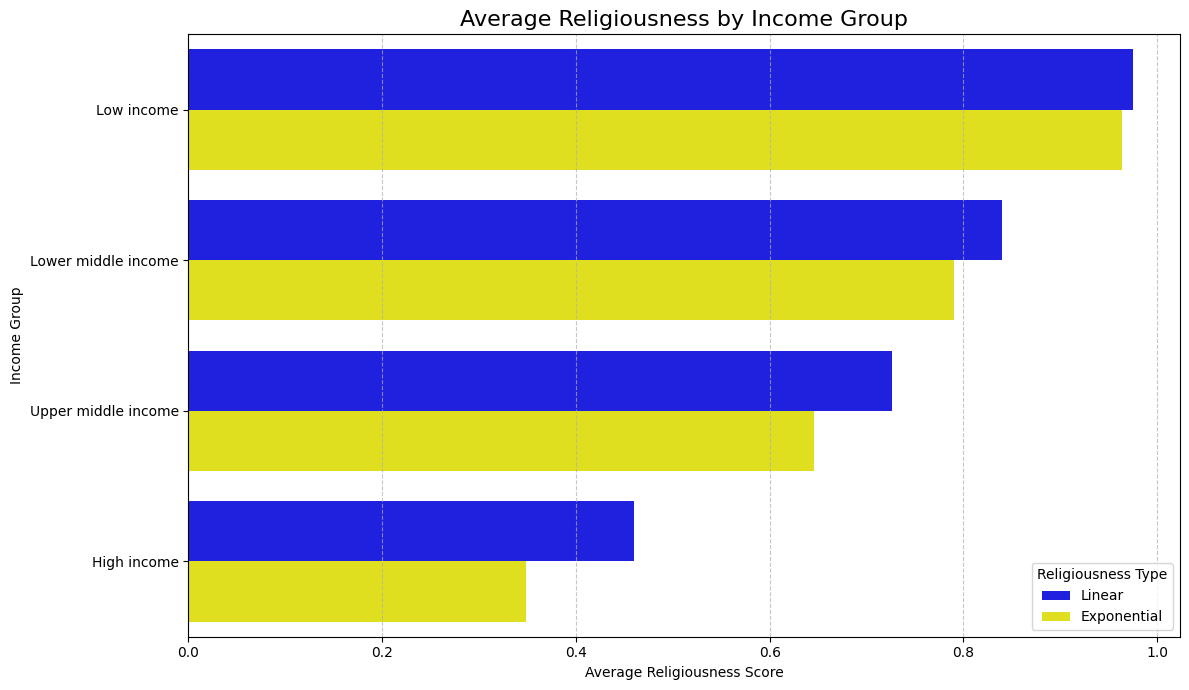

In [ ]:


# Calculate average religiousness by Income Group for linear and exponential metrics
avg_religiousness_income = table1.groupby('Income Group')[['weighted_religiousness_linear', 'weighted_religiousness_exp']].mean().reset_index()

# Sort Income Group by 'weighted_religiousness_linear' for a consistent order on the y-axis
avg_religiousness_income_sorted = avg_religiousness_income.sort_values('weighted_religiousness_linear', ascending=False)

# Melt the DataFrame to long format for plotting both metrics on the same bar chart
melted_religiousness = avg_religiousness_income_sorted.melt(
    id_vars='Income Group',
    value_vars=['weighted_religiousness_linear', 'weighted_religiousness_exp'],
    var_name='Religiousness Type',
    value_name='Average Religiousness Score'
)

# Rename the 'Religiousness Type' for better legend readability
melted_religiousness['Religiousness Type'] = melted_religiousness['Religiousness Type'].replace({
    'weighted_religiousness_linear': 'Linear',
    'weighted_religiousness_exp': 'Exponential'
})

# Define a custom color palette
custom_palette = {
    'Linear': 'blue',
    'Exponential': 'yellow'
}

plt.figure(figsize=(12, 7))
sns.barplot(
    x='Average Religiousness Score',
    y='Income Group',
    hue='Religiousness Type',
    data=melted_religiousness,
    palette=custom_palette
)

plt.title('Average Religiousness by Income Group', fontsize=16)
plt.xlabel('Average Religiousness Score')
plt.ylabel('Income Group')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(title='Religiousness Type')
plt.tight_layout()
plt.show()

### Table 2: GDP Trends and Importance of Religion

This table shows GDP trends and the importance of religion for countries in 2010 and the most recent year (priority 2022, then 2020), as well as changes between these periods.

In [ ]:
# Get 2010 data
importance_2010 = importance[importance['year'] == 2010].copy()

# Get 2022/2020 data (prioritizing 2022)
importance_202x = get_most_recent_year_data(importance, 2022, 2020)

# Merge 2010 data with countries
merged_2010_gdp = pd.merge(importance_2010, countries_prep, on='code', how='inner')
merged_2010_gdp = merged_2010_gdp[['entity_x', 'code', 'year', 'weighted_religiousness_linear', 'weighted_religiousness_exp', 'GDP2010']]
merged_2010_gdp = merged_2010_gdp.rename(columns={
    'year': 'year_2010',
    'weighted_religiousness_linear': 'religiousness_linear_2010',
    'weighted_religiousness_exp': 'religiousness_exp_2010',
    'GDP per capita': 'GDP_2010'
})

# Merge 202x data with countries
merged_202x_gdp = pd.merge(importance_202x, countries_prep, on='code', how='inner')
merged_202x_gdp = merged_202x_gdp[['entity_x', 'code', 'year', 'weighted_religiousness_linear', 'weighted_religiousness_exp', 'GDP2020']]
merged_202x_gdp = merged_202x_gdp.rename(columns={
    'year': 'year_2022',
    'weighted_religiousness_linear': 'religiousness_linear_2022',
    'weighted_religiousness_exp': 'religiousness_exp_2022',
    'GDP per capita': 'GDP_2022'
})

# Combine the two dataframes based on 'entity' and 'code'
table2 = pd.merge(merged_2010_gdp, merged_202x_gdp, on=['entity_x', 'code'], how='inner')

# Calculate trends
table2['GDP_Change'] = (1 - table2['GDP2020'] / table2['GDP2010']) * 100
table2['Religiousness_Linear_Change'] = table2['religiousness_linear_2022'] - table2['religiousness_linear_2010']
table2['Religiousness_Exp_Change'] = table2['religiousness_exp_2022'] - table2['religiousness_exp_2010']

display(table2.head())

,entity_x,code,year_2010,religiousness_linear_2010,religiousness_exp_2010,GDP2010,year_2022,religiousness_linear_2022,religiousness_exp_2022,GDP2020,GDP_Change,Religiousness_Linear_Change,Religiousness_Exp_Change
0,Albania,ALB,2010,0.498018,0.374110,4094.349686,2022,0.619325,0.504882,5343.037704,-30.497835,0.121307,0.130772
1,Andorra,AND,2010,0.323090,0.217153,48237.890541,2022,0.342475,0.233633,37207.238871,22.867193,0.019385,0.016480
2,Argentina,ARG,2010,0.624363,0.518117,10385.964432,2022,0.571411,0.450700,8500.837939,18.150712,-0.052952,-0.067417
3,Armenia,ARM,2010,0.754047,0.663473,3143.029480,2022,0.782043,0.706915,4505.867742,-43.360658,0.027996,0.043442
4,Australia,AUS,2010,0.429065,0.325296,52147.024194,2022,0.337753,0.247009,51868.247557,0.534597,-0.091313,-0.078287


In [ ]:
# Function to analyze direct and inverse relationships given the definition of change columns
def analyze_trends(df, indicator_change_col, religiousness_linear_col, religiousness_exp_col, indicator_name):
    print(f"\n--- {indicator_name} Change vs Religiousness Change Trends ---")

    # Filter out rows with NaN values in relevant change columns
    analysis_df = df.dropna(subset=[indicator_change_col, religiousness_linear_col, religiousness_exp_col])

    # Comparing with Religiousness Linear Change
    print(f"**Comparing {indicator_name} Change with Religiousness Linear Change:**")
    # Definition of trends for indicator_change_col (e.g., GDP_Change):
    #   - If indicator_change_col < 0: Indicator value INCREASED
    #   - If indicator_change_col > 0: Indicator value DECREASED
    # Definition of trends for religiousness_change_col:
    #   - If religiousness_change_col > 0: Religiousness INCREASED
    #   - If religiousness_change_col < 0: Religiousness DECREASED

    # Direct relationship: both metrics increase OR both metrics decrease
    direct_linear_count = analysis_df[
        ((analysis_df[indicator_change_col] < 0) & (analysis_df[religiousness_linear_col] > 0)) |  # Indicator increases, Religiousness increases
        ((analysis_df[indicator_change_col] > 0) & (analysis_df[religiousness_linear_col] < 0))    # Indicator decreases, Religiousness decreases
    ].shape[0]

    # Inverse relationship: one metric increases, other decreases
    inverse_linear_count = analysis_df[
        ((analysis_df[indicator_change_col] < 0) & (analysis_df[religiousness_linear_col] < 0)) |  # Indicator increases, Religiousness decreases
        ((analysis_df[indicator_change_col] > 0) & (analysis_df[religiousness_linear_col] > 0))    # Indicator decreases, Religiousness increases
    ].shape[0]

    print(f"  Direct relationship (both increase/decrease): {direct_linear_count} countries")
    print(f"  Inverse relationship (one increases, other decreases): {inverse_linear_count} countries")
    print(f"  Total countries analyzed (Linear Religiousness): {direct_linear_count + inverse_linear_count}")

    # Comparing with Religiousness Exponential Change
    print(f"\n**Comparing {indicator_name} Change with Religiousness Exponential Change:**")

    # Direct relationship: both metrics increase OR both metrics decrease
    direct_exp_count = analysis_df[
        ((analysis_df[indicator_change_col] < 0) & (analysis_df[religiousness_exp_col] > 0)) |  # Indicator increases, Religiousness increases
        ((analysis_df[indicator_change_col] > 0) & (analysis_df[religiousness_exp_col] < 0))    # Indicator decreases, Religiousness decreases
    ].shape[0]

    # Inverse relationship: one metric increases, other decreases
    inverse_exp_count = analysis_df[
        ((analysis_df[indicator_change_col] < 0) & (analysis_df[religiousness_exp_col] < 0)) |  # Indicator increases, Religiousness decreases
        ((analysis_df[indicator_change_col] > 0) & (analysis_df[religiousness_exp_col] > 0))    # Indicator decreases, Religiousness increases
    ].shape[0]

    print(f"  Direct relationship (both increase/decrease): {direct_exp_count} countries")
    print(f"  Inverse relationship (one increases, other decreases): {inverse_exp_count} countries")
    print(f"  Total countries analyzed (Exponential Religiousness): {direct_exp_count + inverse_exp_count}")

In [ ]:
# Perform analysis for Table 2
analyze_trends(table2, 'GDP_Change', 'Religiousness_Linear_Change', 'Religiousness_Exp_Change', 'GDP')


--- GDP Change vs Religiousness Change Trends ---
**Comparing GDP Change with Religiousness Linear Change:**
  Direct relationship (both increase/decrease): 31 countries
  Inverse relationship (one increases, other decreases): 34 countries
  Total countries analyzed (Linear Religiousness): 65

**Comparing GDP Change with Religiousness Exponential Change:**
  Direct relationship (both increase/decrease): 34 countries
  Inverse relationship (one increases, other decreases): 31 countries
  Total countries analyzed (Exponential Religiousness): 65


### Table 3: Trends in Life Expectancy and Importance of Religion

This table shows trends in life expectancy and the importance of religion for countries in 2010 and the most recent year (priority 2022, then 2020), as well as changes between these periods.

In [ ]:
# Get 2010 data
importance_2010 = importance[importance['year'] == 2010].copy()

# Get 2022/2020 data (prioritizing 2022)
importance_202x = get_most_recent_year_data(importance, 2022, 2020)

# Merge 2010 data with countries
merged_2010_le = pd.merge(importance_2010, countries_prep, on='code', how='inner')
merged_2010_le = merged_2010_le[['entity_x', 'code', 'year', 'weighted_religiousness_linear', 'weighted_religiousness_exp', 'Expectancy2010']]
merged_2010_le = merged_2010_le.rename(columns={
    'year': 'year_2010',
    'weighted_religiousness_linear': 'religiousness_linear_2010',
    'weighted_religiousness_exp': 'religiousness_exp_2010',
    'Life Expectancy': 'Life_Expectancy_2010'
})

# Merge 202x data with countries
merged_202x_le = pd.merge(importance_202x, countries_prep, on='code', how='inner')
merged_202x_le = merged_202x_le[['entity_x', 'code', 'year', 'weighted_religiousness_linear', 'weighted_religiousness_exp', 'Expectancy2020']]
merged_202x_le = merged_202x_le.rename(columns={
    'year': 'year_202x',
    'weighted_religiousness_linear': 'religiousness_linear_202x',
    'weighted_religiousness_exp': 'religiousness_exp_202x',
    'Life Expectancy': 'Life_Expectancy_202x'
})

# Combine the two dataframes based on 'entity' and 'code'
table3 = pd.merge(merged_2010_le, merged_202x_le, on=['entity_x', 'code'], how='inner')

# Calculate trends
table3['Life_Expectancy_Change'] = table3['Expectancy2020'] - table3['Expectancy2010']
table3['Religiousness_Linear_Change'] = table3['religiousness_linear_202x'] - table3['religiousness_linear_2010']
table3['Religiousness_Exp_Change'] = table3['religiousness_exp_202x'] - table3['religiousness_exp_2010']

display(table3.head())

,entity_x,code,year_2010,religiousness_linear_2010,religiousness_exp_2010,Expectancy2010,year_202x,religiousness_linear_202x,religiousness_exp_202x,Expectancy2020,Life_Expectancy_Change,Religiousness_Linear_Change,Religiousness_Exp_Change
0,Albania,ALB,2010,0.498018,0.374110,77.936000,2022,0.619325,0.504882,76.989,-0.947000,0.121307,0.130772
1,Andorra,AND,2010,0.323090,0.217153,NaN,2022,0.342475,0.233633,NaN,NaN,0.019385,0.016480
2,Argentina,ARG,2010,0.624363,0.518117,75.721000,2022,0.571411,0.450700,75.892,0.171000,-0.052952,-0.067417
3,Armenia,ARM,2010,0.754047,0.663473,73.160000,2022,0.782043,0.706915,72.173,-0.987000,0.027996,0.043442
4,Australia,AUS,2010,0.429065,0.325296,81.695122,2022,0.337753,0.247009,83.200,1.504878,-0.091313,-0.078287


In [ ]:
# Perform analysis for Table 3
analyze_trends(table3, 'Life_Expectancy_Change', 'Religiousness_Linear_Change', 'Religiousness_Exp_Change', 'Life Expectancy')


--- Life Expectancy Change vs Religiousness Change Trends ---
**Comparing Life Expectancy Change with Religiousness Linear Change:**
  Direct relationship (both increase/decrease): 40 countries
  Inverse relationship (one increases, other decreases): 24 countries
  Total countries analyzed (Linear Religiousness): 64

**Comparing Life Expectancy Change with Religiousness Exponential Change:**
  Direct relationship (both increase/decrease): 39 countries
  Inverse relationship (one increases, other decreases): 25 countries
  Total countries analyzed (Exponential Religiousness): 64


### Table 4: Fertility Trends and Importance of Religion

This table shows fertility trends and the importance of religion for countries in 2010 and the most recent year (priority 2022, then 2020), as well as changes between these periods.

In [ ]:
# Get 2010 data
importance_2010 = importance[importance['year'] == 2010].copy()

# Get 2022/2020 data (prioritizing 2022)
importance_202x = get_most_recent_year_data(importance, 2022, 2020)

# Merge 2010 data with countries
merged_2010_fert = pd.merge(importance_2010, countries_prep, on='code', how='inner')
merged_2010_fert = merged_2010_fert[['entity_x', 'code', 'year', 'weighted_religiousness_linear', 'weighted_religiousness_exp', 'Fertility2010']]
merged_2010_fert = merged_2010_fert.rename(columns={
    'year': 'year_2010',
    'weighted_religiousness_linear': 'religiousness_linear_2010',
    'weighted_religiousness_exp': 'religiousness_exp_2010',
    'Fertility rate': 'Fertility_rate_2010'
})

# Merge 202x data with countries
merged_202x_fert = pd.merge(importance_202x, countries_prep, on='code', how='inner')
merged_202x_fert = merged_202x_fert[['entity_x', 'code', 'year', 'weighted_religiousness_linear', 'weighted_religiousness_exp', 'Fertility2020']]
merged_202x_fert = merged_202x_fert.rename(columns={
    'year': 'year_202x',
    'weighted_religiousness_linear': 'religiousness_linear_202x',
    'weighted_religiousness_exp': 'religiousness_exp_202x',
    'Fertility rate': 'Fertility_rate_202x'
})

# Combine the two dataframes based on 'entity' and 'code'
table4 = pd.merge(merged_2010_fert, merged_202x_fert, on=['entity_x', 'code'], how='inner')

# Calculate trends
table4['Fertility_rate_Change'] = (1 - table4['Fertility2020'] / table4['Fertility2010']) * 100
table4['Religiousness_Linear_Change'] = table4['religiousness_linear_202x'] - table4['religiousness_linear_2010']
table4['Religiousness_Exp_Change'] = table4['religiousness_exp_202x'] - table4['religiousness_exp_2010']

display(table4.head())

,entity_x,code,year_2010,religiousness_linear_2010,religiousness_exp_2010,Fertility2010,year_202x,religiousness_linear_202x,religiousness_exp_202x,Fertility2020,Fertility_rate_Change,Religiousness_Linear_Change,Religiousness_Exp_Change
0,Albania,ALB,2010,0.498018,0.374110,1.656,2022,0.619325,0.504882,1.400,15.458937,0.121307,0.130772
1,Andorra,AND,2010,0.323090,0.217153,1.270,2022,0.342475,0.233633,NaN,NaN,0.019385,0.016480
2,Argentina,ARG,2010,0.624363,0.518117,2.346,2022,0.571411,0.450700,1.911,18.542199,-0.052952,-0.067417
3,Armenia,ARM,2010,0.754047,0.663473,1.501,2022,0.782043,0.706915,1.575,-4.930047,0.027996,0.043442
4,Australia,AUS,2010,0.429065,0.325296,1.928,2022,0.337753,0.247009,1.581,17.997925,-0.091313,-0.078287


In [ ]:
# Perform analysis for Table 4
analyze_trends(table4, 'Fertility_rate_Change', 'Religiousness_Linear_Change', 'Religiousness_Exp_Change', 'Fertility Rate')


--- Fertility Rate Change vs Religiousness Change Trends ---
**Comparing Fertility Rate Change with Religiousness Linear Change:**
  Direct relationship (both increase/decrease): 43 countries
  Inverse relationship (one increases, other decreases): 20 countries
  Total countries analyzed (Linear Religiousness): 63

**Comparing Fertility Rate Change with Religiousness Exponential Change:**
  Direct relationship (both increase/decrease): 42 countries
  Inverse relationship (one increases, other decreases): 21 countries
  Total countries analyzed (Exponential Religiousness): 63
